# Results Summary

This notebook reads the aggregate CSV files in `results/analysis` and compares the downstream MLP heads with simple baselines.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

DATASET = ROOT / "data" / "validity_dataset"
CANDIDATES = DATASET / "candidates"
FEATURES = DATASET / "features"
HEADS = ROOT / "models" / "validity_heads"
RESULTS = ROOT / "results" / "analysis"

print(f"Repository root: {ROOT}")

Repository root: C:\Users\visha\OneDrive\Desktop\tokenizer-paper-workspace\planfm-validity


In [2]:
story = pd.read_csv(RESULTS / "story_summary.csv")
print(story.shape)
story.head()

(28, 18)


,method,family,split,num_runs,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,auroc_mean,auroc_std,auprc_mean,auprc_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std
0,corruption_type_diagnostic,diagnostic,test-extrapolation,3,1.000000,0.000000e+00,1.000000,0.000000e+00,1.000000,0.000000e+00,1.00000,0.000000e+00,1.00000,0.0,1.00000,0.0,1.0,0.0
1,corruption_type_diagnostic,diagnostic,test-interpolation,3,1.000000,0.000000e+00,1.000000,0.000000e+00,1.000000,0.000000e+00,1.00000,0.000000e+00,1.00000,0.0,1.00000,0.0,1.0,0.0
2,corruption_type_diagnostic,diagnostic,train,3,0.999135,1.110223e-16,0.999459,1.110223e-16,0.999459,1.110223e-16,0.99569,0.000000e+00,0.99784,0.0,0.99569,0.0,1.0,0.0
3,corruption_type_diagnostic,diagnostic,validation,3,1.000000,0.000000e+00,1.000000,0.000000e+00,1.000000,0.000000e+00,1.00000,0.000000e+00,1.00000,0.0,1.00000,0.0,1.0,0.0
4,majority,baseline,test-extrapolation,3,0.800000,1.110223e-16,0.500000,0.000000e+00,0.500000,0.000000e+00,0.20000,2.775558e-17,0.00000,0.0,0.00000,0.0,0.0,0.0


In [3]:
mlp = story[story["method"].str.startswith("mlp_threshold")].copy()
cols = ["family", "split", "num_runs", "balanced_accuracy_mean", "auroc_mean", "auprc_mean", "f1_mean"]
mlp[cols].sort_values(["split", "family"])

,family,split,num_runs,balanced_accuracy_mean,auroc_mean,auprc_mean,f1_mean
8,ad_lstm_wl_delta,test-extrapolation,3,0.548230,0.785734,0.581815,0.177489
12,ad_xgb_wl_delta,test-extrapolation,3,0.709707,0.894026,0.646731,0.485993
16,dd_lstm_shortest_path_delta,test-extrapolation,3,0.683913,0.836701,0.546165,0.442690
20,dd_xgb_wl_delta,test-extrapolation,3,0.587607,0.894776,0.674225,0.296807
9,ad_lstm_wl_delta,test-interpolation,3,0.947115,0.968442,0.936988,0.905714
13,ad_xgb_wl_delta,test-interpolation,3,0.903045,0.969336,0.918373,0.807033
17,dd_lstm_shortest_path_delta,test-interpolation,3,0.884615,0.953649,0.891337,0.771623
21,dd_xgb_wl_delta,test-interpolation,3,0.932692,0.979382,0.939758,0.831994
10,ad_lstm_wl_delta,train,3,0.995495,0.999459,0.997637,0.982298
14,ad_xgb_wl_delta,train,3,0.987927,0.999142,0.996499,0.956241


In [4]:
baselines = story[~story["method"].str.startswith("mlp_threshold")].copy()
baselines[["method", "family", "split", "balanced_accuracy_mean", "auroc_mean", "f1_mean"]].sort_values(["method", "split"])

,method,family,split,balanced_accuracy_mean,auroc_mean,f1_mean
0,corruption_type_diagnostic,diagnostic,test-extrapolation,1.000000,1.000000,1.000000
1,corruption_type_diagnostic,diagnostic,test-interpolation,1.000000,1.000000,1.000000
2,corruption_type_diagnostic,diagnostic,train,0.999459,0.999459,0.997840
3,corruption_type_diagnostic,diagnostic,validation,1.000000,1.000000,1.000000
4,majority,baseline,test-extrapolation,0.500000,0.500000,0.000000
5,majority,baseline,test-interpolation,0.500000,0.500000,0.000000
6,majority,baseline,train,0.500000,0.500000,0.000000
7,majority,baseline,validation,0.500000,0.500000,0.000000
24,plan_length_logreg,baseline,test-extrapolation,0.500000,0.461934,0.067073
25,plan_length_logreg,baseline,test-interpolation,0.564904,0.594767,0.344444


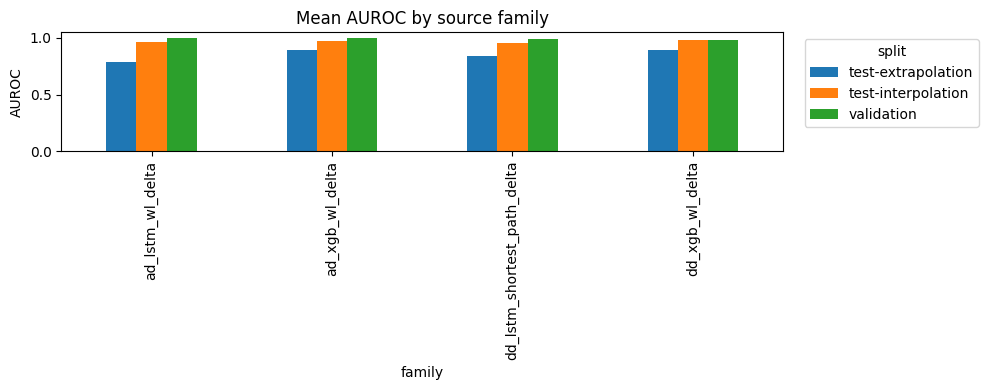

In [5]:
import matplotlib.pyplot as plt

plot_df = mlp[mlp["split"].isin(["validation", "test-interpolation", "test-extrapolation"])].copy()
pivot = plot_df.pivot(index="family", columns="split", values="auroc_mean")
ax = pivot.plot(kind="bar", figsize=(10, 4), ylim=(0.0, 1.05))
ax.set_title("Mean AUROC by source family")
ax.set_ylabel("AUROC")
ax.legend(title="split", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [6]:
# Show the best MLP family per evaluation split by AUROC.
best = (
    mlp[mlp["split"].isin(["validation", "test-interpolation", "test-extrapolation"])]
    .sort_values("auroc_mean", ascending=False)
    .groupby("split")
    .head(1)
    [["split", "family", "auroc_mean", "balanced_accuracy_mean", "auprc_mean", "f1_mean"]]
)
best

,split,family,auroc_mean,balanced_accuracy_mean,auprc_mean,f1_mean
11,validation,ad_lstm_wl_delta,0.998010,0.992424,0.991924,0.971148
21,test-interpolation,dd_xgb_wl_delta,0.979382,0.932692,0.939758,0.831994
20,test-extrapolation,dd_xgb_wl_delta,0.894776,0.587607,0.674225,0.296807
